In [71]:
import numpy as np
import uproot
import matplotlib.pyplot as plt
import pandas as pd

In [98]:
ff = uproot.open("../build/output/outfile_macrogas.root")
ff.keys()
tree = ff['simData']
# tree.show()

field_names = ['pid', 'eventid', 'trackid', 'parentid', 'volumeid', 
               'stepnumber', 'inenergy', 'kineticenergy', 
               'depenergy', 'x','y','z','px','py','pz']

df = tree.arrays(field_names, library='pd')

# Group by eventid and volumeid, then sum depenergy. Only sums for a unique combination
# of eventid and volumeid.
energy_sum = df.groupby(['eventid', 'volumeid'])['depenergy'].sum().reset_index()

idx = df.groupby(['eventid', 'volumeid'])['stepnumber'].idxmin()
xyz_df = df.loc[idx, ['eventid', 'volumeid', 'x', 'y', 'z']]

result = pd.merge(energy_sum, xyz_df, on=['eventid', 'volumeid'])
    


In [101]:
result[result['volumeid']==6]

,eventid,volumeid,depenergy,x,y,z
0,0,6,3.012810e-24,-22.020035,17.257960,110.422437
1,1,6,1.976808e-25,-33.398541,16.123550,114.276942
2,2,6,3.786640e-24,-20.094474,-3.584330,121.735352
3,3,6,1.774419e-25,-2.939544,-13.981563,36.021495
4,4,6,4.502289e-25,5.964241,6.141618,62.345030
...,...,...,...,...,...,...
2076,1995,6,7.447767e-25,-10.462775,-2.823398,100.277239
2077,1996,6,1.021182e-24,2.416102,11.601357,77.874137
2078,1997,6,3.659283e-25,-61.753878,-0.242152,106.958295
2079,1998,6,6.446034e-25,-8.184541,0.953600,144.458521


(array([75., 81., 63., 69., 67., 63., 66., 86., 82., 68., 72., 63., 72.,
        59., 51., 64., 58., 64., 62., 56., 43., 30., 34., 27., 36., 26.,
        22., 22., 26., 21., 19., 22., 12., 22., 20.,  8., 14., 14., 14.,
        19.,  8., 11.,  5., 10.,  7.,  8.,  6., 10.,  5.,  8.,  5.,  8.,
         1.,  6.,  3.,  3.,  3.,  5.,  4.,  7.,  3.,  1.,  1.,  4.,  3.,
         1.,  2.,  2.,  6.,  1.,  3.,  1.,  0.,  1.,  0.,  2.,  3.,  1.,
         1.,  1.,  0.,  2.,  1.,  1.,  2.,  0.,  5.,  1.,  0.,  1.,  2.,
         1.,  3.,  1.,  2.,  1.,  1.,  1.,  0.,  1.,  1.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  1.,  0.,  0.,  1.,  0.,  0.,  0.,  1.,  1.,
         0.,  1.,  1.,  0.,  0.,  1.,  2.,  0.,  0.,  0.,  1.,  2.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.

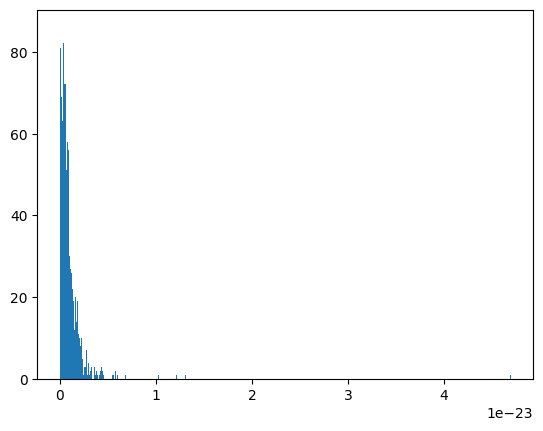

In [69]:
plt.hist(energy_sum[energy_sum['volumeid'] == 6]['depenergy'], bins=1000)

In [48]:
# Three filters that will filter to just the origin events. 
df1 = df[df['trackid']==1]
df1 = df1[df1['stepnumber']==1]
df1 = df1[df1['volumeid']==6]

len(df1)

2000

3352

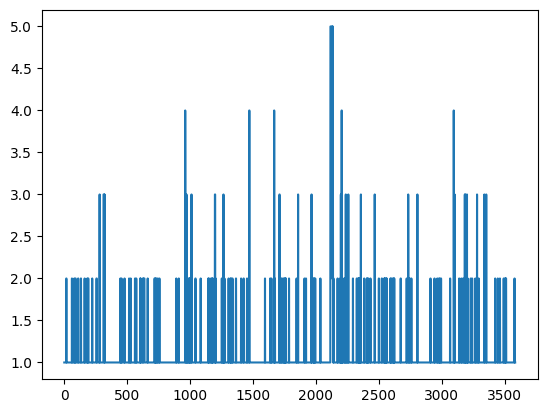

In [23]:
field_name = 'trackid'
x_arr = tree.arrays([field_name], library='np')[field_name]
# x_arr = x_arr[x_arr != 999]  # remove untriggered events
plt.plot(x_arr)
len(x_arr[x_arr == 1])


In [7]:
# task - find if any of these are nonzero

arr = tree.arrays(["detVac_En"], library='np')
len(arr['detVac_En'])
np.mean(arr['detVac_En'])
print(len(ff['simData']['detWind_En'].array()))

en = ff['simData']['detWind_En'].array() 
print(len(en))
print(len(en[en > 0]))

2000
2000
52


In [8]:
en

<Array [0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0] type='2000 * float64'>

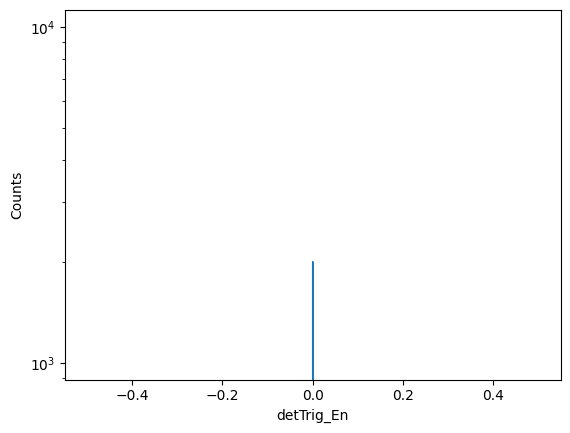

In [15]:

plt.hist(ff['simData']['detTrig_En'].array(), bins=1000, histtype='step')
plt.xlabel('detTrig_En')
plt.ylabel('Counts')
plt.yscale('log')
# plt.ylim(0,10)
plt.show()

[-11, 22, 999]


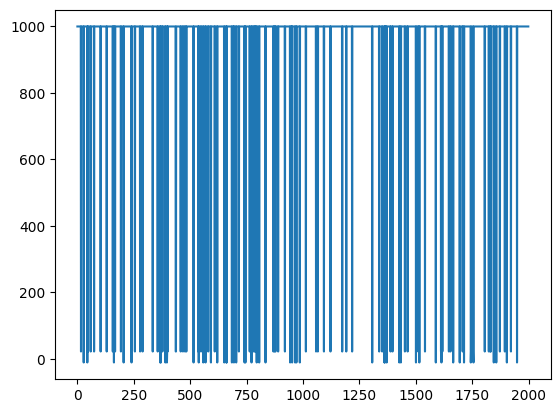

In [44]:
plt.plot(ff['simData']['detWind_ID'].array())
pid = ff['simData']['detWind_ID'].array()
pid_unique = np.unique(pid)
print(pid_unique)


In [25]:
print(dir(tree))

['__abstractmethods__', '__class__', '__class_getitem__', '__contains__', '__delattr__', '__dict__', '__dir__', '__doc__', '__enter__', '__eq__', '__exit__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__reversed__', '__setattr__', '__setstate__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_bases', '_chunk', '_concrete', '_cursor', '_deeply_writable', '_eager_arrays', '_file', '_instance_version', '_ipython_key_completions_', '_is_memberwise', '_lookup', '_members', '_num_bytes', '_parent', '_serialize', '_to_writable', '_to_writable_postprocess', '_virtual_arrays', 'aliases', 'all_members', 'arrays', 'awkward_form', 'base', 'base_names_versions', 'bases', 'behaviors', 'branches', 'cache_key', 'check_numbytes', 'chunk', 'class_code', 'cla

In [30]:
for k in tree.keys():
    print(k)

detSQ_ID
detSQ_En
detSQ_InEn
detSQ_Inx
detSQ_Iny
detSQ_Inz
detTrig_ID
detTrig_En
detTrig_InEn
detTrig_Inx
detTrig_Iny
detTrig_Inz
detWind_ID
detWind_En
detWind_InEn
detWind_Inx
detWind_Iny
detWind_Inz
detVac_ID
detVac_En
detVac_InEn
detVac_Inx
detVac_Iny
detVac_Inz


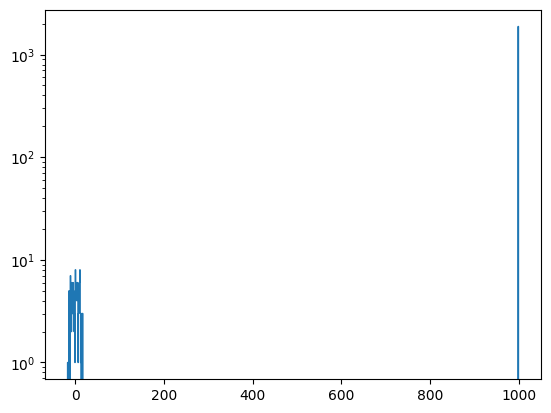

In [22]:
plt.hist(ff['simData']['detWind_Iny'].array(), bins=1000, histtype='step')
plt.yscale('log')
plt.show()